# Pipeline Tiền Xử Lý Văn Bản Tiếng Việt (Vietnamese NLP Preprocessing)

Notebook này bao gồm đầy đủ các bước tiền xử lý văn bản tiếng Việt:
1. Đọc dữ liệu
2. Chuyển thành chữ thường (Lowercasing)
3. Loại bỏ dấu câu (Remove Punctuation)
4. Chuẩn hóa văn bản (Text Normalization)
5. Sửa lỗi chính tả (Spell Checking)
6. Tách từ (Tokenization)
7. Loại bỏ stop words
8. Stemming/Lemmatization
9. Trực quan hóa dữ liệu
10. Pipeline hoàn chỉnh

## 0. Cài đặt thư viện cần thiết

In [1]:
# Cài đặt các thư viện cần thiết (chạy 1 lần)
# !pip install underthesea
# !pip install wordcloud
# !pip install matplotlib

# Import các thư viện
from underthesea import word_tokenize
from collections import Counter
import matplotlib.pyplot as plt
import json

print("✓ Đã import tất cả thư viện thành công!")

✓ Đã import tất cả thư viện thành công!


## 1. Đọc dữ liệu từ file

In [2]:
with open('test.md', 'r', encoding='utf-8') as file:
    content = file.read()
    
print("Độ dài của nội dung trong file là:", len(content))
print("\nNội dung của file là:\n")
print(content)

Độ dài của nội dung trong file là: 266

Nội dung của file là:

      Ketoconazol 2% là thuốc thuốc có hoạt tính kháng nấm mạnh được sử dụng để điều trị các bệnh nấm ở da và niêm mạc. Người bệnh nên tìm hiểu kỹ các thông tin về thuốc, đồng thời tham khảo ý kiến của bác sĩ trước khi sử dụng thuốc Ketoconazol 2% để điều trị bệnh.



1. Chuyển văn bản thành chữ thường (lowercase).

In [3]:
content_lower = content.lower()
print("\nNội dung sau khi chuyển thành chữ thường:\n")
print(content_lower)


Nội dung sau khi chuyển thành chữ thường:

      ketoconazol 2% là thuốc thuốc có hoạt tính kháng nấm mạnh được sử dụng để điều trị các bệnh nấm ở da và niêm mạc. người bệnh nên tìm hiểu kỹ các thông tin về thuốc, đồng thời tham khảo ý kiến của bác sĩ trước khi sử dụng thuốc ketoconazol 2% để điều trị bệnh.



2. Loại bỏ dấu câu (punctuation).

In [4]:
punctuation_to_remove = '''!()-[]{};:'"\,<>./?@#$^&*_~'''
content_no_punctuation = ''.join(char for char in content_lower if char not in punctuation_to_remove)
print("\nNội dung sau khi loại bỏ dấu câu:\n")
print(content_no_punctuation)


Nội dung sau khi loại bỏ dấu câu:

      ketoconazol 2% là thuốc thuốc có hoạt tính kháng nấm mạnh được sử dụng để điều trị các bệnh nấm ở da và niêm mạc người bệnh nên tìm hiểu kỹ các thông tin về thuốc đồng thời tham khảo ý kiến của bác sĩ trước khi sử dụng thuốc ketoconazol 2% để điều trị bệnh



3. Loại bỏ các từ dừng (stop words).

In [5]:
from underthesea import word_tokenize
with open('vietnamese-stopwords.txt', 'r', encoding='utf-8') as f:
    stop_words = set(f.read().splitlines())
    
words = word_tokenize(content_no_punctuation)
filtered_words = [word for word in words if word not in stop_words]
content_no_stopwords = ' '.join(filtered_words)

print("\nNội dung sau khi loại bỏ stop words:\n")
print(content_no_stopwords)


Nội dung sau khi loại bỏ stop words:

ketoconazol 2 % thuốc thuốc hoạt tính kháng nấm mạnh sử dụng điều trị bệnh nấm da niêm mạc người bệnh tìm hiểu kỹ thông tin thuốc đồng thời tham khảo ý kiến bác sĩ sử dụng thuốc ketoconazol 2 % điều trị bệnh


4. Chuẩn hóa văn bản (viết tắt thành đầy đủ).

In [6]:
# Chuẩn hóa văn bản - Chuyển các từ viết tắt thành đầy đủ
abbreviations = {
    'TP.HCM': 'Thành phố Hồ Chí Minh',
    'tp.hcm': 'thành phố hồ chí minh',
    'TP HCM': 'Thành phố Hồ Chí Minh',
    'HN': 'Hà Nội',
    'hn': 'hà nội',
    'VN': 'Việt Nam',
    'vn': 'việt nam',
    'TPHCM': 'Thành phố Hồ Chí Minh',
    'tphcm': 'thành phố hồ chí minh',
    'ĐH': 'Đại học',
    'đh': 'đại học',
    'TT': 'Trung tâm',
    'tt': 'trung tâm',
    'BS': 'Bác sĩ',
    'bs': 'bác sĩ',
    'ThS': 'Thạc sĩ',
    'ths': 'thạc sĩ',
    'PGS': 'Phó Giáo sư',
    'pgs': 'phó giáo sư',
    'GS': 'Giáo sư',
    'gs': 'giáo sư'
}

def normalize_abbreviations(text, abbrev_dict):
    """Chuẩn hóa các từ viết tắt trong văn bản"""
    for abbrev, full in abbrev_dict.items():
        text = text.replace(abbrev, full)
    return text

# Áp dụng chuẩn hóa
content_normalized = normalize_abbreviations(content_no_punctuation, abbreviations)
print("\nNội dung sau khi chuẩn hóa viết tắt:\n")
print(content_normalized[:500], "...")  # In 500 ký tự đầu


Nội dung sau khi chuẩn hóa viết tắt:

      ketoconazol 2% là thuốc thuốc có hoạt tính kháng nấm mạnh được sử dụng để điều trị các bệnh nấm ở da và niêm mạc người bệnh nên tìm hiểu kỹ các thông tin về thuốc đồng thời tham khảo ý kiến của bác sĩ trước khi sử dụng thuốc ketoconazol 2% để điều trị bệnh
 ...


5. Phát hiện lỗi chính tả từ dữ liệu thực tế.

In [7]:
# Phát hiện lỗi chính tả từ dữ liệu thực tế
# Cách 1: Tìm các từ xuất hiện ít (có thể là lỗi đánh máy)

from collections import Counter

# Đếm tần suất tất cả các từ
word_freq = Counter(words)

# Tìm các từ xuất hiện ít (có thể sai chính tả)
rare_words = {word: count for word, count in word_freq.items() 
              if count <= 2 and len(word) > 1}  # Xuất hiện <= 2 lần

print(f"\n✓ Tìm thấy {len(rare_words)} từ hiếm (có thể sai chính tả)")
print("\nTop 20 từ hiếm:")
for i, (word, count) in enumerate(sorted(rare_words.items(), key=lambda x: x[1], reverse=True)[:20], 1):
    print(f"  {i}. '{word}' xuất hiện {count} lần")

# Cách 2: Tìm các từ có ký tự lạ hoặc độ dài bất thường
suspicious_words = []
for word in words:
    # Kiểm tra từ quá ngắn hoặc có số
    if (len(word) <= 2 or 
        any(char.isdigit() for char in word) or
        word.startswith('_') or word.endswith('_')):
        suspicious_words.append(word)

print(f"\n✓ Tìm thấy {len(set(suspicious_words))} từ nghi ngờ (có ký tự lạ)")
print("Ví dụ 10 từ nghi ngờ:", list(set(suspicious_words))[:10])


✓ Tìm thấy 29 từ hiếm (có thể sai chính tả)

Top 20 từ hiếm:
  1. 'ketoconazol' xuất hiện 2 lần
  2. 'nấm' xuất hiện 2 lần
  3. 'sử dụng' xuất hiện 2 lần
  4. 'để' xuất hiện 2 lần
  5. 'điều trị' xuất hiện 2 lần
  6. 'các' xuất hiện 2 lần
  7. 'bệnh' xuất hiện 2 lần
  8. 'là' xuất hiện 1 lần
  9. 'có' xuất hiện 1 lần
  10. 'hoạt tính' xuất hiện 1 lần
  11. 'kháng' xuất hiện 1 lần
  12. 'mạnh' xuất hiện 1 lần
  13. 'được' xuất hiện 1 lần
  14. 'da' xuất hiện 1 lần
  15. 'và' xuất hiện 1 lần
  16. 'niêm mạc' xuất hiện 1 lần
  17. 'người bệnh' xuất hiện 1 lần
  18. 'nên' xuất hiện 1 lần
  19. 'tìm hiểu' xuất hiện 1 lần
  20. 'kỹ' xuất hiện 1 lần

✓ Tìm thấy 10 từ nghi ngờ (có ký tự lạ)
Ví dụ 10 từ nghi ngờ: ['ở', '%', 'kỹ', 'da', 'và', '2', 'để', 'có', 'về', 'là']


6. Tokenization (tách từ).

In [8]:
words = word_tokenize(content_no_stopwords)
print("\nTokenized words:\n")
print(words)


Tokenized words:

['ketoconazol', '2', '%', 'thuốc', 'thuốc', 'hoạt tính', 'kháng', 'nấm', 'mạnh', 'sử dụng', 'điều trị', 'bệnh', 'nấm', 'da', 'niêm mạc', 'người bệnh', 'tìm hiểu', 'kỹ', 'thông tin', 'thuốc', 'đồng thời', 'tham khảo', 'ý kiến', 'bác sĩ', 'sử dụng', 'thuốc', 'ketoconazol', '2', '%', 'điều trị', 'bệnh']


7. Lemmatization - Chuẩn hóa từ về dạng gốc (cho tiếng Việt).

In [9]:
# Lemmatization cho tiếng Việt
# Tiếng Việt không có biến thể dạng từ như tiếng Anh
# Nhưng ta có thể chuẩn hóa các từ đồng nghĩa, từ ghép, và thuật ngữ y tế

# Tạo từ điển lemmatization cho thuật ngữ y tế
lemma_dict = {
    # Chuẩn hóa từ ghép
    'y tế': 'y_tế',
    'ytế': 'y_tế',
    'y-tế': 'y_tế',
    
    'bệnh viện': 'bệnh_viện',
    'bệnhviện': 'bệnh_viện',
    'bệnh-viện': 'bệnh_viện',
    
    'bác sĩ': 'bác_sĩ',
    'bácsĩ': 'bác_sĩ',
    'bác-sĩ': 'bác_sĩ',
    
    'bệnh nhân': 'bệnh_nhân',
    'bệnhnhân': 'bệnh_nhân',
    
    'sức khỏe': 'sức_khỏe',
    'sứckhỏe': 'sức_khỏe',
    
    'điều trị': 'điều_trị',
    'điềutrị': 'điều_trị',
    
    'chẩn đoán': 'chẩn_đoán',
    'chẩnđoán': 'chẩn_đoán',
    
    'triệu chứng': 'triệu_chứng',
    'triệuchứng': 'triệu_chứng',
    
    'xét nghiệm': 'xét_nghiệm',
    'xétnghiệm': 'xét_nghiệm',
    
    # Chuẩn hóa viết tắt
    'tp.hcm': 'thành_phố_hồ_chí_minh',
    'tphcm': 'thành_phố_hồ_chí_minh',
    'tp hcm': 'thành_phố_hồ_chí_minh',
    
    'bs': 'bác_sĩ',
    'bs.': 'bác_sĩ',
    
    'bv': 'bệnh_viện',
    'bv.': 'bệnh_viện',
    
    'bn': 'bệnh_nhân',
    'bn.': 'bệnh_nhân',
    
    'xn': 'xét_nghiệm',
    'xn.': 'xét_nghiệm'
}

def lemmatize_words(words, lemma_dict):
    """Áp dụng lemmatization cho danh sách từ"""
    lemmatized = []
    for word in words:
        # Tìm dạng chuẩn của từ
        lemma = lemma_dict.get(word, word)
        lemmatized.append(lemma)
    return lemmatized

# Áp dụng lemmatization
words_lemmatized = lemmatize_words(words, lemma_dict)

print("\nSố từ duy nhất trước lemmatization:", len(set(words)))
print("Số từ duy nhất sau lemmatization:", len(set(words_lemmatized)))
print(f"\nĐã giảm {len(set(words)) - len(set(words_lemmatized))} từ trùng lặp")

print("\nVí dụ 15 từ sau lemmatization:")
print(words_lemmatized[:15])


Số từ duy nhất trước lemmatization: 21
Số từ duy nhất sau lemmatization: 21

Đã giảm 0 từ trùng lặp

Ví dụ 15 từ sau lemmatization:
['ketoconazol', '2', '%', 'thuốc', 'thuốc', 'hoạt tính', 'kháng', 'nấm', 'mạnh', 'sử dụng', 'điều_trị', 'bệnh', 'nấm', 'da', 'niêm mạc']


8. Khám phá và trực quan hóa dữ liệu văn bản.

        a.Đếm tần suất từ (word frequency).

In [10]:
from collections import Counter

# Đếm số lần xuất hiện của mỗi từ
word_freq = Counter(words)
print("Top 10 từ phổ biến nhất:")
print(word_freq.most_common(10))

Top 10 từ phổ biến nhất:
[('thuốc', 4), ('ketoconazol', 2), ('2', 2), ('%', 2), ('nấm', 2), ('sử dụng', 2), ('điều trị', 2), ('bệnh', 2), ('hoạt tính', 1), ('kháng', 1)]


        b. Vẽ biểu đồ từ phổ biến.

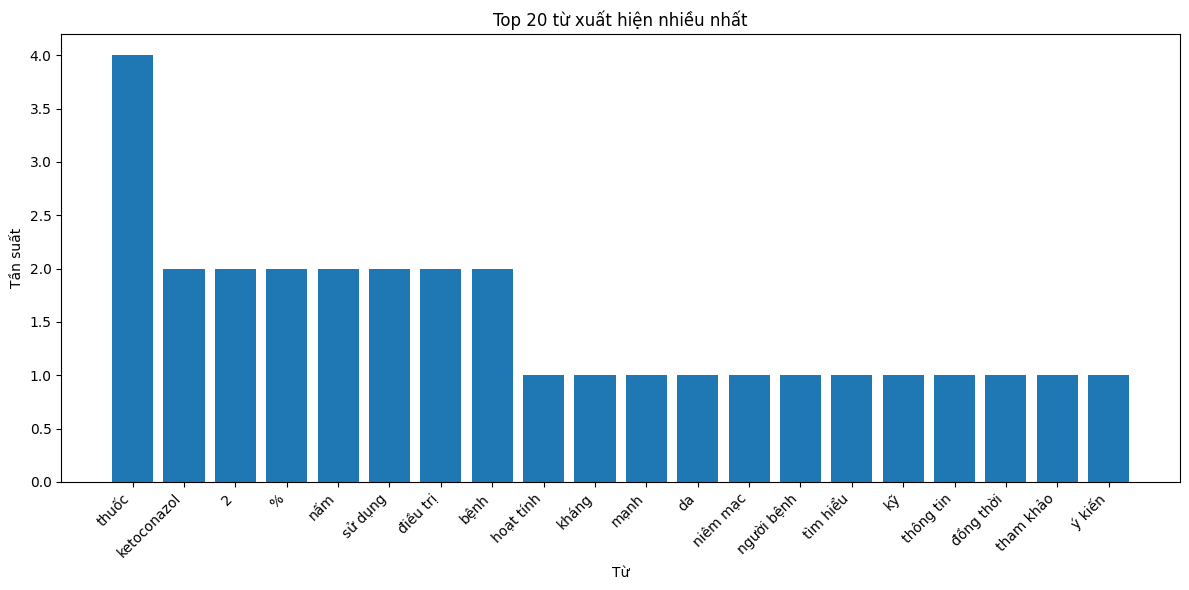

In [11]:
import matplotlib.pyplot as plt

# Lấy top 20 từ
top_words = dict(word_freq.most_common(20))
plt.figure(figsize=(12, 6))
plt.bar(top_words.keys(), top_words.values())
plt.xticks(rotation=45, ha='right')
plt.xlabel('Từ')
plt.ylabel('Tần suất')
plt.title('Top 20 từ xuất hiện nhiều nhất')
plt.tight_layout()
plt.show()

        c. Tạo word cloud.


[notice] A new release of pip is available: 25.0.1 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


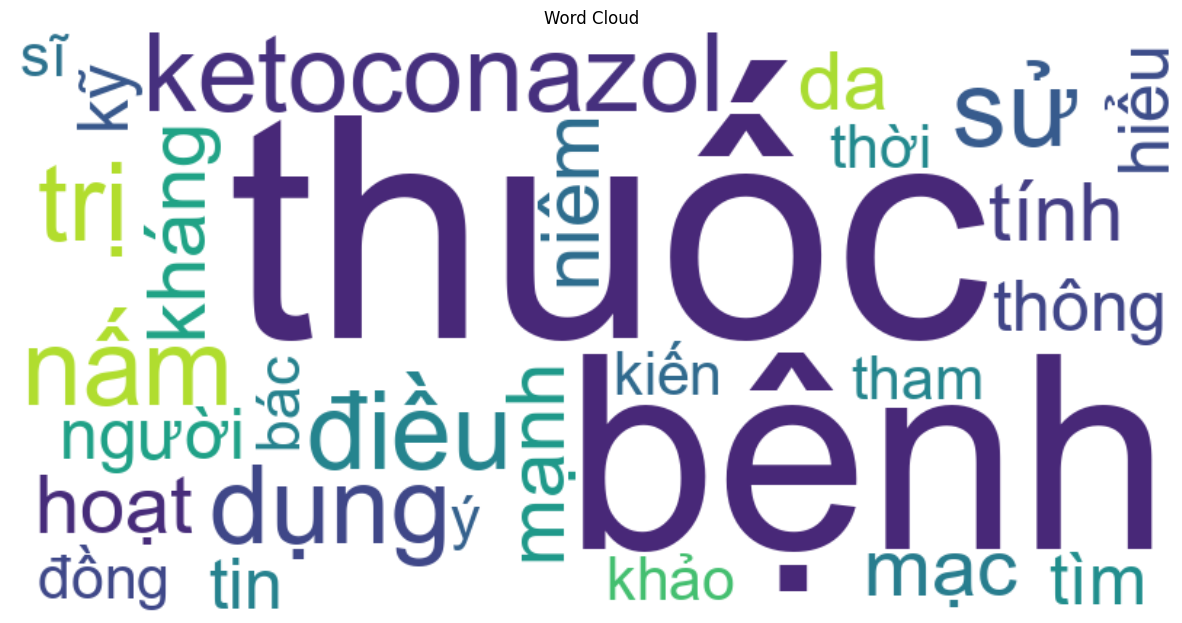

In [12]:
%pip install wordcloud

from wordcloud import WordCloud

# Tạo word cloud
wordcloud = WordCloud(width=800, height=400, 
                      background_color='white',
                      font_path='arial.ttf').generate(content_no_stopwords)

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud')
plt.show()

        d. Phân tích độ dài văn bản.

In [13]:
# Thống kê
print(f"Tổng số từ: {len(words)}")
print(f"Số từ duy nhất: {len(set(words))}")
print(f"Độ dài trung bình của từ: {sum(len(word) for word in words) / len(words):.2f}")

Tổng số từ: 31
Số từ duy nhất: 21
Độ dài trung bình của từ: 5.71


        e. Phân tích N-gram (cụm từ).
        

In [14]:
from collections import Counter

# Tạo bigrams (cặp từ liên tiếp)
bigrams = [(words[i], words[i+1]) for i in range(len(words)-1)]
bigram_freq = Counter(bigrams)
print("Top 10 cụm từ phổ biến:")
print(bigram_freq.most_common(10))

Top 10 cụm từ phổ biến:
[(('ketoconazol', '2'), 2), (('2', '%'), 2), (('điều trị', 'bệnh'), 2), (('%', 'thuốc'), 1), (('thuốc', 'thuốc'), 1), (('thuốc', 'hoạt tính'), 1), (('hoạt tính', 'kháng'), 1), (('kháng', 'nấm'), 1), (('nấm', 'mạnh'), 1), (('mạnh', 'sử dụng'), 1)]


9. Pipeline hoàn chỉnh.

In [15]:
from underthesea import word_tokenize
from collections import Counter

def preprocess_vietnamese_text(file_path, stopwords_path):
    """
    Pipeline hoàn chỉnh để tiền xử lý văn bản tiếng Việt
    
    Args:
        file_path: Đường dẫn đến file văn bản
        stopwords_path: Đường dẫn đến file chứa stop words
        
    Returns:
        dict chứa kết quả các bước xử lý
    """
    print("=" * 60)
    print("PIPELINE TIỀN XỬ LÝ VĂN BẢN TIẾNG VIỆT")
    print("=" * 60)
    
    # Bước 1: Đọc file
    print("\n[Bước 1] Đọc file...")
    with open(file_path, 'r', encoding='utf-8') as file:
        content = file.read()
    print(f"✓ Đã đọc file. Độ dài: {len(content)} ký tự")
    
    # Bước 2: Chuyển thành chữ thường
    print("\n[Bước 2] Chuyển thành chữ thường...")
    content_lower = content.lower()
    print("✓ Hoàn thành")
    
    # Bước 3: Loại bỏ dấu câu
    print("\n[Bước 3] Loại bỏ dấu câu...")
    punctuation_to_remove = '''!()-[]{};:'"\,<>./?@#$^&*_~'''
    content_no_punct = ''.join(char for char in content_lower if char not in punctuation_to_remove)
    print(f"✓ Đã loại bỏ {len(content_lower) - len(content_no_punct)} ký tự dấu câu")
    
    # Bước 4: Tách từ (Word Tokenization)
    print("\n[Bước 4] Tách từ (Word Tokenization)...")
    words_raw = word_tokenize(content_no_punct)
    print(f"✓ Đã tách thành {len(words_raw)} từ")
    
    # Bước 5: Loại bỏ stop words
    print("\n[Bước 5] Loại bỏ stop words...")
    with open(stopwords_path, 'r', encoding='utf-8') as f:
        stop_words = set(f.read().splitlines())
    
    filtered_words = [word for word in words_raw if word not in stop_words]
    print(f"✓ Đã loại bỏ {len(words_raw) - len(filtered_words)} stop words")
    print(f"✓ Còn lại {len(filtered_words)} từ")
    
    # Bước 6: Thống kê
    print("\n[Bước 6] Thống kê dữ liệu...")
    word_freq = Counter(filtered_words)
    unique_words = len(set(filtered_words))
    avg_word_length = sum(len(word) for word in filtered_words) / len(filtered_words) if filtered_words else 0
    
    print(f"✓ Số từ duy nhất: {unique_words}")
    print(f"✓ Độ dài trung bình của từ: {avg_word_length:.2f} ký tự")
    
    # Bước 7: Top từ phổ biến
    print("\n[Bước 7] Top 10 từ phổ biến nhất:")
    for i, (word, count) in enumerate(word_freq.most_common(10), 1):
        print(f"  {i}. '{word}': {count} lần")
    
    print("\n" + "=" * 60)
    print("HOÀN THÀNH PIPELINE")
    print("=" * 60)
    
    # Trả về kết quả
    return {
        'original': content,
        'lowercased': content_lower,
        'no_punctuation': content_no_punct,
        'words': filtered_words,
        'word_frequency': word_freq,
        'statistics': {
            'total_words': len(filtered_words),
            'unique_words': unique_words,
            'avg_word_length': avg_word_length
        }
    }

# Chạy pipeline
result = preprocess_vietnamese_text('test.md', 'vietnamese-stopwords.txt')

# Lưu kết quả đã xử lý
with open('processed_output.txt', 'w', encoding='utf-8') as f:
    f.write(' '.join(result['words']))
print("\n✓ Đã lưu kết quả vào file 'processed_output.txt'")

PIPELINE TIỀN XỬ LÝ VĂN BẢN TIẾNG VIỆT

[Bước 1] Đọc file...
✓ Đã đọc file. Độ dài: 266 ký tự

[Bước 2] Chuyển thành chữ thường...
✓ Hoàn thành

[Bước 3] Loại bỏ dấu câu...
✓ Đã loại bỏ 3 ký tự dấu câu

[Bước 4] Tách từ (Word Tokenization)...
✓ Đã tách thành 45 từ

[Bước 5] Loại bỏ stop words...
✓ Đã loại bỏ 14 stop words
✓ Còn lại 31 từ

[Bước 6] Thống kê dữ liệu...
✓ Số từ duy nhất: 21
✓ Độ dài trung bình của từ: 5.71 ký tự

[Bước 7] Top 10 từ phổ biến nhất:
  1. 'thuốc': 4 lần
  2. 'ketoconazol': 2 lần
  3. '2': 2 lần
  4. '%': 2 lần
  5. 'nấm': 2 lần
  6. 'sử dụng': 2 lần
  7. 'điều trị': 2 lần
  8. 'bệnh': 2 lần
  9. 'hoạt tính': 1 lần
  10. 'kháng': 1 lần

HOÀN THÀNH PIPELINE

✓ Đã lưu kết quả vào file 'processed_output.txt'
